# 03 Feature Engineering

In this notebook, we perform feature engineering after removing extreme price outliers.

Input dataset:
- dataset/price_outliers_removed_dataset.csv

Main goals:
1. Create useful features for analysis and modeling.
2. Analyze the relationship between price and demand.
3. Save a new dataset after feature engineering.

Important note:
The previous notebook handled price outliers using the 99th percentile method.
This notebook does not remove additional outliers.

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [66]:
df = pd.read_csv("../dataset/price_outliers_removed_dataset.csv")

print("Dataset loaded successfully")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully
Shape: (107529, 23)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,order_estimated_delivery_date,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,2017-09-29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,2017-05-15,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,2018-02-05,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,2018-08-20,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,2017-03-17,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,garden_tools


In [67]:
df.info()
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 107529 entries, 0 to 107528
Data columns (total 23 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       107529 non-null  str    
 1   order_item_id                  107529 non-null  int64  
 2   product_id                     107529 non-null  str    
 3   seller_id                      107529 non-null  str    
 4   shipping_limit_date            107529 non-null  str    
 5   price                          107529 non-null  float64
 6   freight_value                  107529 non-null  float64
 7   customer_id                    107529 non-null  str    
 8   order_status                   107529 non-null  str    
 9   order_purchase_timestamp       107529 non-null  str    
 10  order_approved_at              107529 non-null  str    
 11  order_delivered_carrier_date   107529 non-null  str    
 12  order_delivered_customer_date  107529 non

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value', 'customer_id',
       'order_status', 'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'product_category_name',
       'product_name_lenght', 'product_description_lenght',
       'product_photos_qty', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm',
       'product_category_name_english'],
      dtype='str')

## Initial Check

Before creating new features, we check missing values and duplicated rows to make sure the dataset is still clean after the previous preparation step.

In [68]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicated rows:", df.duplicated().sum())

Missing values:
order_id                         0
order_item_id                    0
product_id                       0
seller_id                        0
shipping_limit_date              0
price                            0
freight_value                    0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
product_category_name            0
product_name_lenght              0
product_description_lenght       0
product_photos_qty               0
product_weight_g                 0
product_length_cm                0
product_height_cm                0
product_width_cm                 0
product_category_name_english    0
dtype: int64

Duplicated rows: 0


## Feature Engineering

We will create new features that can help us better understand product price behavior and the relationship between price and demand.

The new features include:
- total_order_item_value
- freight_ratio
- product_volume_cm3
- price_range
- freight_level
- product_size_level

### total_order_item_value

This feature represents the total cost paid by the customer for one item, including both product price and freight cost.

It was created because customer purchase decisions are affected by the final cost, not only the product price. A product with a low price but high shipping cost may be less attractive to customers.

In [69]:
df["total_order_item_value"] = df["price"] + df["freight_value"]

df[["price", "freight_value", "total_order_item_value"]].head()

,price,freight_value,total_order_item_value
0,58.90,13.29,72.19
1,239.90,19.93,259.83
2,199.00,17.87,216.87
3,12.99,12.79,25.78
4,199.90,18.14,218.04


### freight_ratio

This feature measures the shipping cost relative to the product price.

It was created because the shipping cost alone may not fully explain customer behavior. For example, a freight value of 50 may be acceptable for an expensive product, but too high for a cheap product.

This feature helps us understand whether the shipping cost is high or low compared to the product price, which may affect customer demand.

In [70]:
df["freight_ratio"] = df["freight_value"] / df["price"]

df["freight_ratio"] = df["freight_ratio"].replace([np.inf, -np.inf], np.nan)
df["freight_ratio"] = df["freight_ratio"].fillna(0)
df["freight_ratio_percent"] = df["freight_ratio"].apply(lambda x: f"{x * 100:.2f}%")

df[["price", "freight_value", "freight_ratio","freight_ratio_percent"]].head()

,price,freight_value,freight_ratio,freight_ratio_percent
0,58.90,13.29,0.225637,22.56%
1,239.90,19.93,0.083076,8.31%
2,199.00,17.87,0.089799,8.98%
3,12.99,12.79,0.984604,98.46%
4,199.90,18.14,0.090745,9.07%


### product_volume_cm3

This feature represents the total physical volume of the product, calculated using product length, height, and width.

It was created because product dimensions individually may be less informative than the overall product volume. Product volume can affect shipping cost, storage requirements, and possibly product pricing.

In [71]:
df["product_volume_cm3"] = (
    df["product_length_cm"] * 
    df["product_height_cm"] * 
    df["product_width_cm"]
)

df[["product_length_cm", "product_height_cm", "product_width_cm", "product_volume_cm3"]].head()

,product_length_cm,product_height_cm,product_width_cm,product_volume_cm3
0,28.0,9.0,14.0,3528.0
1,50.0,30.0,40.0,60000.0
2,33.0,13.0,33.0,14157.0
3,16.0,10.0,15.0,2400.0
4,35.0,40.0,30.0,42000.0


### price_range

This feature converts the continuous price column into price categories such as Very Low, Low, Medium, High, and Very High.

It was created to make price analysis easier and more interpretable. Instead of analyzing each price value separately, we can compare demand across different price ranges.

This is especially useful for analyzing the relationship between price and demand.

In [72]:
df["price_range"] = pd.cut(
    df["price"],
    bins=[0, 50, 100, 200, 500, df["price"].max()],
    labels=["Very Low", "Low", "Medium", "High", "Very High"],
    include_lowest=True
)
df[['price','price_range']].head()

,price,price_range
0,58.90,Low
1,239.90,High
2,199.00,Medium
3,12.99,Very Low
4,199.90,Medium


### freight_level

This feature converts the freight value into shipping cost categories.

It was created to make shipping cost analysis easier. Freight cost can influence customer purchasing decisions, especially when the shipping cost is high compared to the product price.

This feature helps compare demand and pricing behavior across different freight levels.

In [73]:
df["freight_level"] = pd.cut(
    df["freight_value"],
    bins=[0, 10, 25, 50, df["freight_value"].max()],
    labels=["Low Freight", "Medium Freight", "High Freight", "Very High Freight"],
    include_lowest=True
)

df[["freight_value", "freight_level"]].head()

,freight_value,freight_level
0,13.29,Medium Freight
1,19.93,Medium Freight
2,17.87,Medium Freight
3,12.79,Medium Freight
4,18.14,Medium Freight


### product_size_level

This feature groups products into size categories: Small, Medium, and Large, based on product volume.

It was created to make product size analysis easier. Instead of using raw volume values, we can compare pricing, shipping cost, and demand across different product size groups.

Quantiles were used because they divide products based on the actual distribution of the dataset.

In [74]:
df["product_size_level"] = pd.cut(
    df["product_volume_cm3"],
    bins=[0, 
          df["product_volume_cm3"].quantile(0.33),
          df["product_volume_cm3"].quantile(0.66),
          df["product_volume_cm3"].max()],
    labels=["Small", "Medium", "Large"],
    include_lowest=True
)

df[["product_volume_cm3", "product_size_level"]].head()

,product_volume_cm3,product_size_level
0,3528.0,Small
1,60000.0,Large
2,14157.0,Large
3,2400.0,Small
4,42000.0,Large


## Demand Feature Creation

Demand is represented as the number of times a product appears in orders.

We create:
- product_demand_count: number of times each product appears in the dataset.
- category_demand_count: number of orders/items per product category.

In [75]:
df["product_demand_count"] = df.groupby("product_id")["product_id"].transform("count")

df[['product_id','product_demand_count']].head()

,product_id,product_demand_count
0,4244733e06e7ecb4970a6e2683c13e61,9
1,e5f2d52b802189ee658865ca93d83a8f,1
2,c777355d18b72b67abbeef9df44fd0fd,3
3,7634da152a4610f1595efa32f14722fc,2
4,ac6c3623068f30de03045865e4e10089,11


Note: `product_demand_count` represents how many times each product appears in the dataset. Since the dataset is at the order-item level, products with higher demand appear in multiple rows.

In [76]:
df["category_demand_count"] = (
    df.groupby("product_category_name_english")["product_category_name_english"]
      .transform("count")
)
df[["product_category_name_english", "price", "category_demand_count"]].head()


,product_category_name_english,price,category_demand_count
0,cool_stuff,58.90,3685
1,pet_shop,239.90,1913
2,furniture_decor,199.00,8144
3,perfumery,12.99,3340
4,garden_tools,199.90,4211


In [77]:
df["category_avg_price"] = df.groupby("product_category_name_english")["price"].transform("mean")
df["category_median_price"] = df.groupby("product_category_name_english")["price"].transform("median")
df["price_vs_category_median"] = df["price"] - df["category_median_price"]

df[[
    "product_category_name_english",
    "price",
    "category_avg_price",
    "category_median_price",
    "price_vs_category_median"
]].round(2).head()

,product_category_name_english,price,category_avg_price,category_median_price,price_vs_category_median
0,cool_stuff,58.90,154.38,129.80,-70.90
1,pet_shop,239.90,102.68,89.70,150.20
2,furniture_decor,199.00,85.40,65.49,133.51
3,perfumery,12.99,116.81,84.99,-72.00
4,garden_tools,199.90,91.53,59.90,140.00


### Interpretation of price_vs_category_median

The `price_vs_category_median` feature shows how each product price compares to the typical price of its category.

- If the value is positive, the product is more expensive than the category median price.
- If the value is negative, the product is cheaper than the category median price.
- If the value is close to zero, the product price is close to the normal price range of its category.

This feature is useful because the same price may be considered cheap in one category and expensive in another category. Therefore, comparing a product price with its category median gives better context than looking at the raw price alone.

## Price and Demand Relationship

In this section, we analyze the relationship between product price and demand.

Demand is represented by:
- product_demand_count
- category_demand_count

We want to understand whether cheaper products tend to have higher demand, and whether expensive products have lower demand.

In [78]:
price_demand_summary = df.groupby("price_range", observed=True).agg(
        avg_price=("price", "mean"),
        median_price=("price", "median"),
        avg_demand=("product_demand_count", "mean"),
        total_items=("product_demand_count", "count")
    ).reset_index()

price_demand_summary["avg_price"] = price_demand_summary["avg_price"].round(2)
price_demand_summary["median_price"] = price_demand_summary["median_price"].round(2)
price_demand_summary["avg_demand"] = price_demand_summary["avg_demand"].round(2)

price_demand_summary

,price_range,avg_price,median_price,avg_demand,total_items
0,Very Low,31.47,29.99,27.11,37888
1,Low,75.13,73.90,56.95,32072
2,Medium,143.71,139.90,33.56,25852
3,High,297.27,279.90,19.67,9744
4,Very High,655.94,630.00,8.79,1973


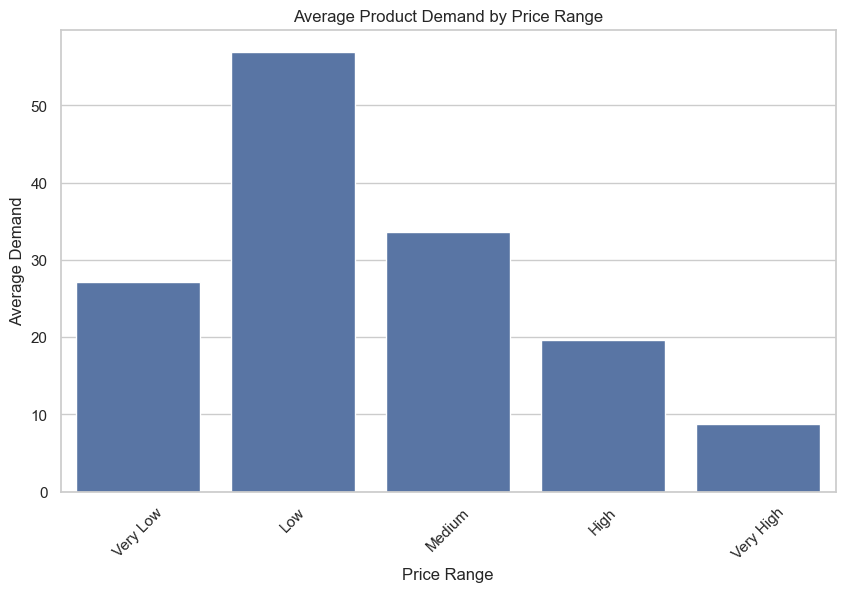

In [79]:
plt.figure(figsize=(10, 6))
sns.barplot(data=price_demand_summary, x="price_range", y="avg_demand")
plt.title("Average Product Demand by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Average Demand")
plt.xticks(rotation=45)
plt.show()

### Observation

The chart shows that the Low price range has the highest average product demand, while demand generally decreases as the price range becomes higher.

However, the Very Low range does not have the highest demand. This means that cheaper products are not always the most demanded products. Demand may also be affected by other factors such as product category, product popularity, shipping cost, and customer need.

Overall, the result suggests a weak negative relationship between price and demand, where higher-priced products tend to have lower demand, but price alone does not fully explain demand.

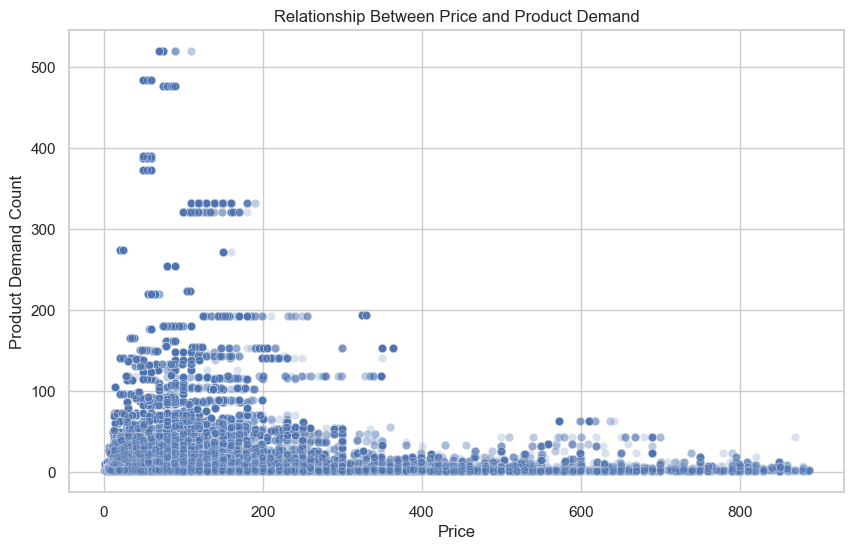

In [80]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="price", y="product_demand_count", alpha=0.2)
plt.title("Relationship Between Price and Product Demand")
plt.xlabel("Price")
plt.ylabel("Product Demand Count")
plt.show()

This scatter plot shows the relationship between product price and product demand.
It helps identify whether products with lower prices are ordered more frequently than expensive products.

In [81]:
price_demand_corr = df["price"].corr(df["product_demand_count"])
print("Correlation between price and product demand:", round(price_demand_corr, 4))

Correlation between price and product demand: -0.064


In [82]:
category_demand_summary = df.groupby("product_category_name_english").agg(
    median_price=("price", "median"),
    avg_price=("price", "mean"),
    total_demand=("order_id", "count") if "order_id" in df.columns else ("price", "count")
    ).reset_index()

category_demand_summary = category_demand_summary.sort_values("total_demand", ascending=False)

category_demand_summary.head(10)


,product_category_name_english,median_price,avg_price,total_demand
7,bed_bath_table,79.00,91.903731,10939
43,health_beauty,79.18,117.593669,9361
65,sports_leisure,75.00,103.032397,8362
39,furniture_decor,65.49,85.398621,8144
15,computers_accessories,80.00,104.478699,7577
49,housewares,59.00,85.370651,6772
70,watches_gifts,124.90,171.015012,5716
68,telephony,29.98,62.623281,4398
42,garden_tools,59.90,91.526701,4211
5,auto,80.00,120.195249,4081


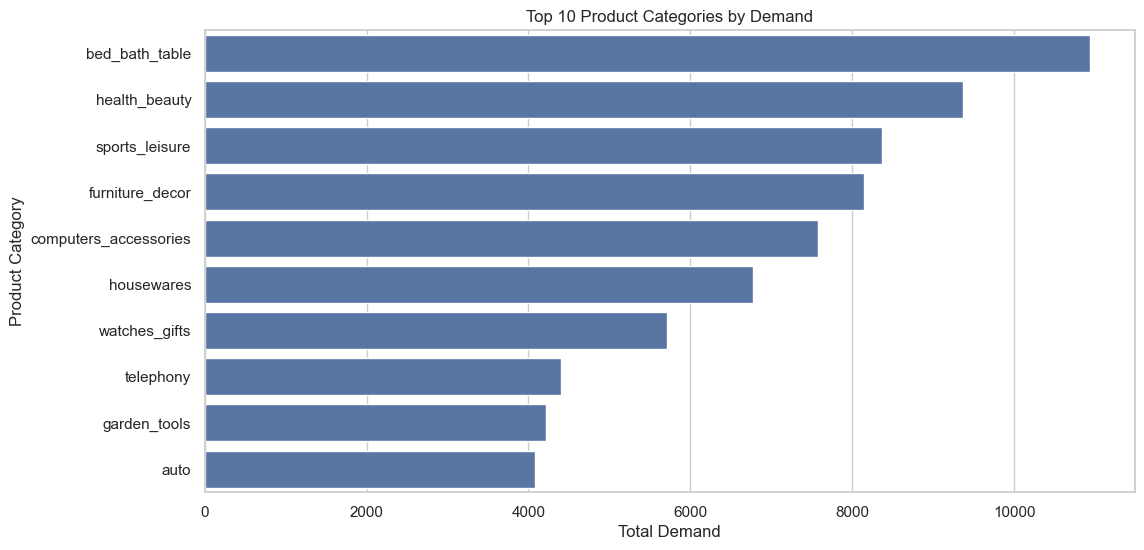

In [83]:
top_categories = category_demand_summary.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_categories, x="total_demand", y="product_category_name_english")
plt.title("Top 10 Product Categories by Demand")
plt.xlabel("Total Demand")
plt.ylabel("Product Category")
plt.show()

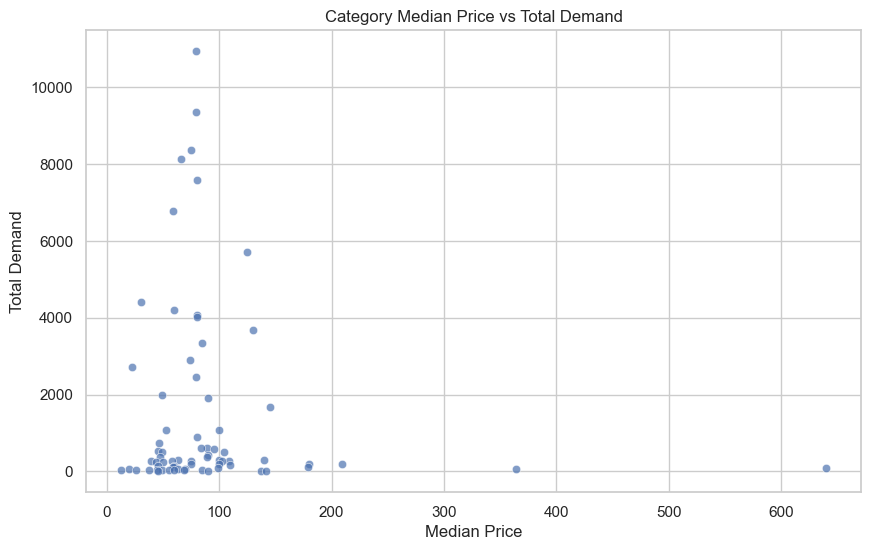

In [84]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=category_demand_summary,
    x="median_price",
    y="total_demand",
    alpha=0.7
    )
plt.title("Category Median Price vs Total Demand")
plt.xlabel("Median Price")
plt.ylabel("Total Demand")
plt.show()

This chart compares the median price of each category with its total demand.
It helps us understand whether categories with lower median prices receive more demand than expensive categories.

In [85]:
print("Final dataset shape:", df.shape)
df.head()

Final dataset shape: (107529, 35)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,freight_ratio_percent,product_volume_cm3,price_range,freight_level,product_size_level,product_demand_count,category_demand_count,category_avg_price,category_median_price,price_vs_category_median
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,22.56%,3528.0,Low,Medium Freight,Small,9,3685,154.382882,129.80,-70.90
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,8.31%,60000.0,High,Medium Freight,Large,1,1913,102.677632,89.70,150.20
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,8.98%,14157.0,Medium,Medium Freight,Large,3,8144,85.398621,65.49,133.51
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,98.46%,2400.0,Very Low,Medium Freight,Small,2,3340,116.809775,84.99,-72.00
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,9.07%,42000.0,Medium,Medium Freight,Large,11,4211,91.526701,59.90,140.00


In [86]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 107529 entries, 0 to 107528
Data columns (total 35 columns):
 #   Column                         Non-Null Count   Dtype   
---  ------                         --------------   -----   
 0   order_id                       107529 non-null  str     
 1   order_item_id                  107529 non-null  int64   
 2   product_id                     107529 non-null  str     
 3   seller_id                      107529 non-null  str     
 4   shipping_limit_date            107529 non-null  str     
 5   price                          107529 non-null  float64 
 6   freight_value                  107529 non-null  float64 
 7   customer_id                    107529 non-null  str     
 8   order_status                   107529 non-null  str     
 9   order_purchase_timestamp       107529 non-null  str     
 10  order_approved_at              107529 non-null  str     
 11  order_delivered_carrier_date   107529 non-null  str     
 12  order_delivered_customer_da

In [87]:
missing_after_fe = df.isnull().sum()
missing_after_fe[missing_after_fe > 0]

Series([], dtype: int64)

In [88]:
output_path = "../dataset/feature_engineered_dataset.csv"

df.to_csv(output_path, index=False)

print("Feature engineered dataset saved successfully at:")
print(output_path)
print("Final shape:", df.shape)

Feature engineered dataset saved successfully at:
../dataset/feature_engineered_dataset.csv
Final shape: (107529, 35)


## Summary

In this notebook, we created several new features to support data analysis and future modeling.

Created features:
- total_order_item_value
- freight_ratio
- product_volume_cm3
- price_range
- freight_level
- product_size_level
- product_demand_count
- category_demand_count
- category_avg_price
- category_median_price
- price_vs_category_median

The correlation between price and product demand was -0.064, which indicates a very weak negative relationship. This means that higher prices may be associated with slightly lower demand, but price alone is not enough to explain product demand.

We also analyzed the relationship between price and demand using:
- Price range vs average demand
- Price vs product demand scatter plot
- Category median price vs total demand

Finally, the feature-engineered dataset was saved as:
dataset/feature_engineered_dataset.csv